## Combining Datasets

This is a first attempt at combining 1. Villanova EB, 2. KOI and 3. Variable Star Catalogs. Good luck to me.

In [ ]:
import lightkurve as lk
import pandas as pd
from astroquery.mast import Mast
from astroquery.mast import Observations

%matplotlib inline

Villanova EB Catalog is Already downloaded (Thanks Desh)

In [3]:
keb = pd.read_csv(r'../assets/data/kepler-eclipsing-binary-catalog.csv')
keb = keb.drop(columns='Unnamed: 11')
keb.head(20)

,KIC,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC
0,3863594,0.053268,0.000000e+00,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False
1,10417986,0.073731,0.000000e+00,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True
2,8912468,0.094838,0.000000e+00,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False
3,8758716,0.107205,0.000000e+00,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False
4,10855535,0.112782,0.000000e+00,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False
5,9472174,0.125765,1.000000e-07,54953.643178,0.018318,0.78,79.0187,11.6745,12.264,10645.0,True
6,9612468,0.133471,1.000000e-07,54953.603803,0.007796,0.99,81.0112,8.5285,11.531,7202.0,False
7,6613627,0.150800,1.000000e-07,55115.344848,0.008552,0.98,75.1606,10.2517,12.548,7090.0,False
8,5302006,0.151171,1.000000e-07,54980.509040,0.007895,0.97,75.3495,6.6449,15.050,6536.0,False
9,9898401,0.152774,1.000000e-07,54964.733972,0.008810,0.99,79.6654,11.8375,12.073,7376.0,False


The key column would be the KIC column, which will be used to merge datasets

## Moving onto Kepler Dataset

In [5]:
search_result = lk.search_lightcurve("Kepler-8", mission="Kepler")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
1,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
2,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
3,Kepler Quarter 02,2009,Kepler,60,kplr006922244,0.0
4,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
5,Kepler Quarter 03,2009,Kepler,60,kplr006922244,0.0
6,Kepler Quarter 00,2009,Kepler,1800,kplr006922244,0.0
7,Kepler Quarter 01,2009,Kepler,1800,kplr006922244,0.0
8,Kepler Quarter 02,2009,Kepler,1800,kplr006922244,0.0


In [15]:
type(search_result)

lightkurve.search.SearchResult

In [4]:
klc = lk.search_lightcurve("Kepler-8", mission="Kepler", quarter=4).download()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 5 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [5]:
klc

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
352.3664488646464,———,———,0,-1.410475e-03,682.69289,190.13203,345880,4.3726242e+04,3.6275974e+01,1.6734445e+03,4.6769428e-01,———,———,0,———,———,———,———,682.69289,1.0144709e-03,190.13203,9.9874916e-04,3.3346944e-02,-6.0084205e-02
352.3671298512636,———,———,0,-1.410489e-03,682.69073,190.13396,345881,4.3655164e+04,3.6252655e+01,1.6733635e+03,4.6769321e-01,———,———,0,———,———,———,———,682.69073,1.0160099e-03,190.13396,9.9957502e-04,3.3344790e-02,-6.0088485e-02
352.3678110378751,———,———,0,-1.410502e-03,682.69084,190.13300,345882,4.3717223e+04,3.6270748e+01,1.6732825e+03,4.6769220e-01,———,———,0,———,———,———,———,682.69084,1.0143395e-03,190.13300,9.9824253e-04,3.3342637e-02,-6.0092766e-02
352.3684921244858,———,———,0,-1.410516e-03,682.69058,190.13325,345883,4.3703078e+04,3.6267101e+01,1.6732014e+03,4.6769118e-01,———,———,0,———,———,———,———,682.69058,1.0146485e-03,190.13325,9.9842646e-04,3.3340488e-02,-6.0097046e-02
352.3691732110965,———,———,0,-1.410529e-03,682.69140,190.13361,345884,4.3723355e+04,3.6269840e+01,1.6731204e+03,4.6769017e-01,———,———,0,———,———,———,———,682.69140,1.0143060e-03,190.13361,9.9832180e-04,3.3338334e-02,-6.0101327e-02
352.3698542977145,———,———,0,-1.410542e-03,682.69096,190.13275,345885,4.3685207e+04,3.6261799e+01,1.6730396e+03,4.6768913e-01,———,———,0,———,———,———,———,682.69096,1.0147295e-03,190.13275,9.9886989e-04,3.3336181e-02,-6.0105603e-02
352.37053548420954,———,———,0,-1.410556e-03,682.69484,190.13304,345886,4.3664211e+04,3.6259644e+01,1.6729585e+03,4.6768811e-01,———,———,0,———,———,———,———,682.69484,1.0161689e-03,190.13304,9.9954498e-04,3.3334032e-02,-6.0109887e-02
352.37121657082025,———,———,0,-1.410569e-03,682.69182,190.13310,345887,4.3707324e+04,3.6272911e+01,1.6728774e+03,4.6768710e-01,———,———,0,———,———,———,———,682.69182,1.0137684e-03,190.13310,9.9839014e-04,3.3331878e-02,-6.0114164e-02


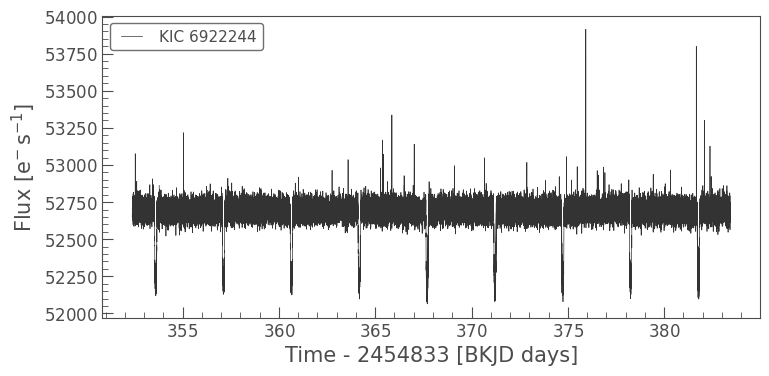

In [6]:
%matplotlib inline
klc.plot();

Using LightCurve only allows you to query each object of interest one by one. It does not seem the most intuitive way to merge datasets.

### Attempting MastMissionsClass

Mast MissionsClass does seem to support Kelper

### Using Observation Queries to Fetch Kepler data

In [26]:

obs = Observations.query_criteria_count(
    obs_collection="Kepler",
    dataproduct_type="timeseries",
)


print(obs)

212954


In [27]:
obs = Observations.query_criteria(
    obs_collection="Kepler",
    dataproduct_type="timeseries",
)


print(obs)

intentType obs_collection provenance_name ... objID  wave_min wave_max
---------- -------------- --------------- ... ------ -------- --------
   science         Kepler          Kepler ... 616921    418.4    905.0
   science         Kepler          Kepler ... 616922    418.4    905.0
   science         Kepler          Kepler ... 616923    418.4    905.0
   science         Kepler          Kepler ... 616924    418.4    905.0
   science         Kepler          Kepler ... 616925    418.4    905.0
   science         Kepler          Kepler ... 616926    418.4    905.0
   science         Kepler          Kepler ... 616927    418.4    905.0
   science         Kepler          Kepler ... 616928    418.4    905.0
   science         Kepler          Kepler ... 616929    418.4    905.0
   science         Kepler          Kepler ... 616930    418.4    905.0
       ...            ...             ... ...    ...      ...      ...
   science         Kepler          Kepler ... 829869    418.4    905.0
   sci

In [28]:
products = Observations.get_product_list(obs[:10])
filtered = Observations.filter_products(
    products,
    productSubGroupDescription="LC",  # 👈 key filter
    extension="fits"
)

In [29]:
from lightkurve import read

manifest = Observations.download_products(filtered)

# Example: read first file
lc = read(manifest['Local Path'][0])

lc.plot()

TypeError: 'NoneType' object is not subscriptable

In [30]:
print("products:", len(products))
print("filtered:", len(filtered))


products: 66
filtered: 0
